In [12]:
from google.colab import files
uploaded = files.upload()  # select your downloaded CSV

Saving archive (1).zip to archive (1).zip


In [13]:
import zipfile

with zipfile.ZipFile('archive (1).zip', 'r') as z:
    print("Files inside zip:")
    print(z.namelist())
    z.extractall('.')

Files inside zip:
['features.csv', 'stores.csv', 'test.csv', 'train.csv']


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [23]:
# Load all files
train    = pd.read_csv('train.csv', parse_dates=['Date'])
test     = pd.read_csv('test.csv', parse_dates=['Date'])
stores   = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv', parse_dates=['Date'])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Stores shape:", stores.shape)
print("Features shape:", features.shape)

print("\n--- TRAIN COLUMNS ---")
print(train.columns.tolist())

print("\n--- FEATURES COLUMNS ---")
print(features.columns.tolist())

print("\n--- STORES COLUMNS ---")
print(stores.columns.tolist())

print("\n--- TRAIN SAMPLE ---")
train.head()

Train shape: (421570, 5)
Test shape: (115064, 4)
Stores shape: (45, 3)
Features shape: (8190, 12)

--- TRAIN COLUMNS ---
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

--- FEATURES COLUMNS ---
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

--- STORES COLUMNS ---
['Store', 'Type', 'Size']

--- TRAIN SAMPLE ---


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [17]:
features.sample(5)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
6707,37,2013-01-25,57.77,3.227,24.85,66.80,NaN,NaN,478.81,222.903230,6.266,False
1599,9,2012-11-02,56.26,3.386,2291.26,2178.48,65.25,20.52,1347.79,227.251326,4.954,False
8116,45,2012-03-02,41.55,3.816,22832.38,2515.25,4.00,13317.88,2560.48,190.171493,8.424,False
7589,42,2012-07-13,89.80,3.723,769.08,NaN,2.36,NaN,2678.63,130.683000,7.170,False
7511,42,2011-01-14,49.98,3.312,NaN,NaN,NaN,NaN,NaN,127.300935,8.744,False


In [19]:
features.isnull().sum()

,0
Store,0
Date,0
Temperature,0
Fuel_Price,0
MarkDown1,4158
MarkDown2,5269
MarkDown3,4577
MarkDown4,4726
MarkDown5,4140
CPI,585


In [20]:
train.isnull().sum()

,0
Store,0
Dept,0
Date,0
Weekly_Sales,0
IsHoliday,0


In [21]:
test.isnull().sum()

,0
Store,0
Dept,0
Date,0
IsHoliday,0


In [22]:
stores.isnull().sum()

,0
Store,0
Type,0
Size,0


#Merge All Data

## Merge train with features and stores

In [24]:
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')

print("Merged shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Merged shape: (421570, 16)

Missing values:
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


#Handle Missing Value

In [26]:
# MarkDown columns have lots of nulls - fill with 0 (no markdown = 0 discount)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

# Fill CPI and Unemployment with median
df['CPI'].fillna(df['CPI'].median(), inplace=True)
df['Unemployment'].fillna(df['Unemployment'].median(), inplace=True)

print("Missing after cleaning:", df.isnull().sum().sum())

Missing after cleaning: 0


#Feature Engineering

In [27]:
# Extract date features
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Week']       = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter']    = df['Date'].dt.quarter

# Total markdown
df['Total_MarkDown'] = df[markdown_cols].sum(axis=1)

# Remove negative sales (data errors)
df = df[df['Weekly_Sales'] > 0]

print("Final shape:", df.shape)
df.head()

Final shape: (420212, 21)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Week,Quarter,Total_MarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,0.0,211.096358,8.106,A,151315,2010,2,5,1,0.0
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,0.0,211.242170,8.106,A,151315,2010,2,6,1,0.0
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,0.0,211.289143,8.106,A,151315,2010,2,7,1,0.0
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,0.0,211.319643,8.106,A,151315,2010,2,8,1,0.0
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,0.0,211.350143,8.106,A,151315,2010,3,9,1,0.0


#EDA Visulization

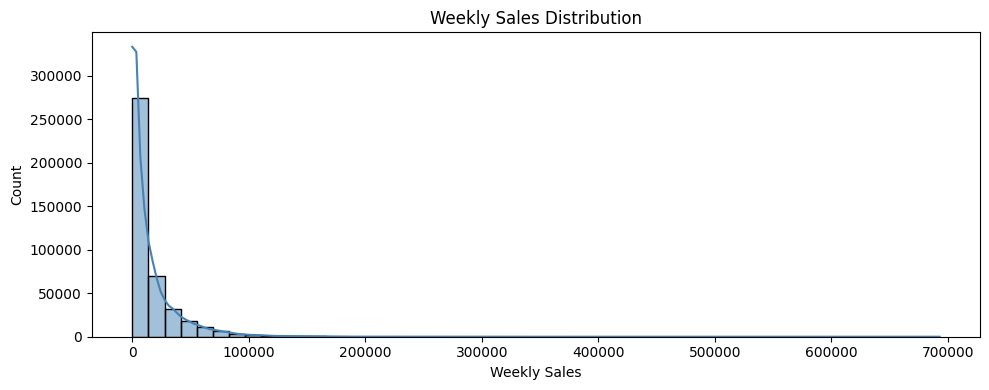

In [28]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color='steelblue')
plt.title('Weekly Sales Distribution')
plt.xlabel('Weekly Sales')
plt.tight_layout()
plt.savefig('sales_distribution.png', dpi=150)
plt.show()

##Monthly Sales Trend:

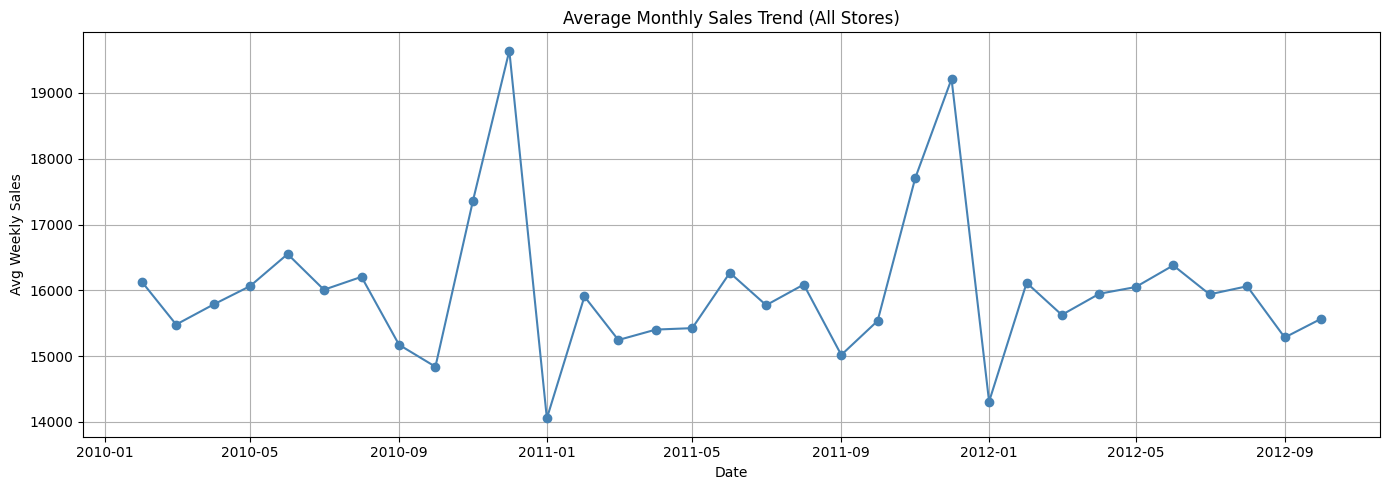

In [29]:
monthly = df.groupby(['Year', 'Month'])['Weekly_Sales'].mean().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Weekly_Sales'], marker='o', color='steelblue')
plt.title('Average Monthly Sales Trend (All Stores)')
plt.xlabel('Date')
plt.ylabel('Avg Weekly Sales')
plt.grid(True)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

##Holiday vs Non-Holiday Sales:

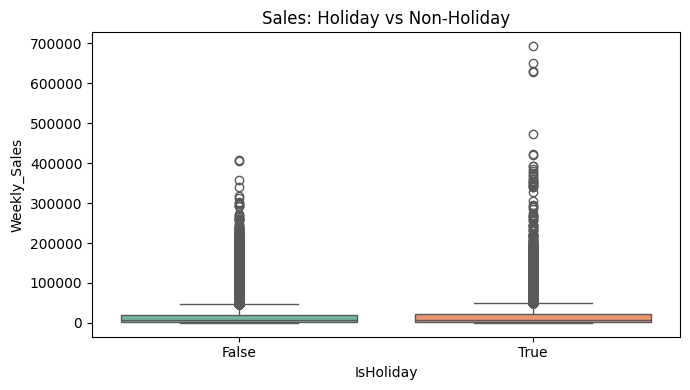

In [30]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df, palette='Set2')
plt.title('Sales: Holiday vs Non-Holiday')
plt.tight_layout()
plt.savefig('holiday_impact.png', dpi=150)
plt.show()

##Store Type Performance

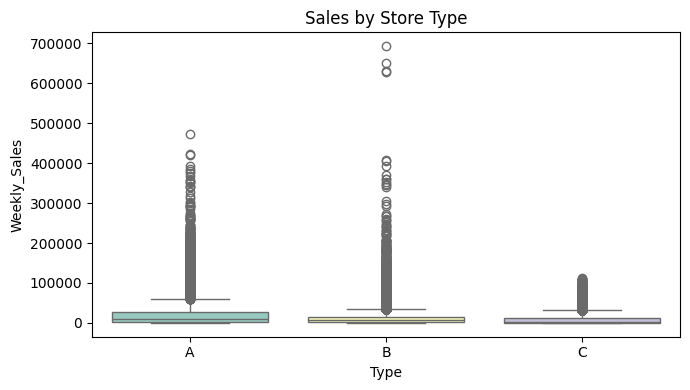

In [31]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='Type', y='Weekly_Sales', data=df, palette='Set3')
plt.title('Sales by Store Type')
plt.tight_layout()
plt.savefig('storetype_sales.png', dpi=150)
plt.show()

##Top 10 Department Sales

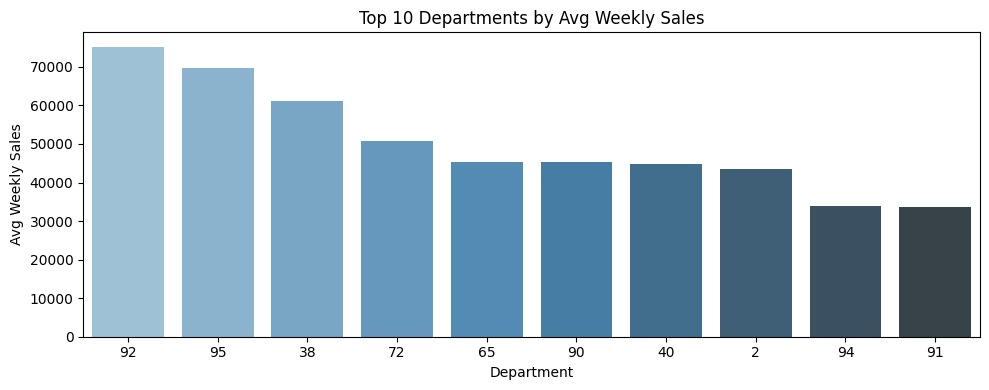

In [32]:
top_depts = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
sns.barplot(x=top_depts.index.astype(str), y=top_depts.values, palette='Blues_d')
plt.title('Top 10 Departments by Avg Weekly Sales')
plt.xlabel('Department')
plt.ylabel('Avg Weekly Sales')
plt.tight_layout()
plt.savefig('top_depts.png', dpi=150)
plt.show()

##Correlation Heatmap

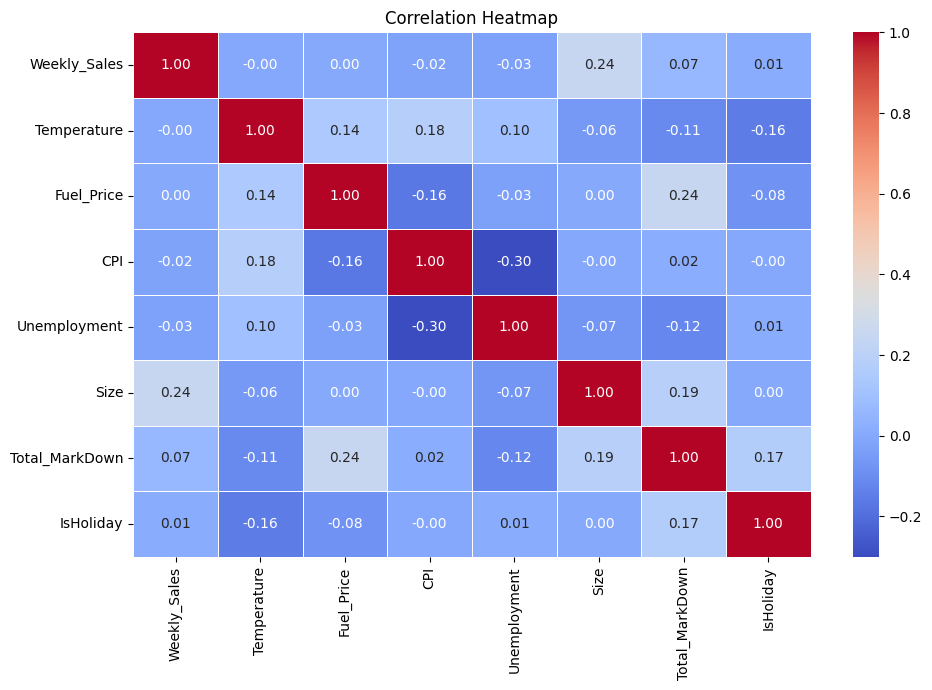

In [33]:
cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
        'Unemployment', 'Size', 'Total_MarkDown', 'IsHoliday']

df_corr = df[cols].copy()
df_corr['IsHoliday'] = df_corr['IsHoliday'].astype(int)

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

#Save Clean Data

In [34]:
df.to_csv('walmart_clean.csv', index=False)
print("Saved! Shape:", df.shape)

Saved! Shape: (420212, 21)
